In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
#Load 
df = pd.read_csv(r'C:\Users\saini\Downloads\employee_attrition_ml_250_rows.csv')

In [ ]:
df.head(3)

,EmployeeID,Age,Department,JobRole,YearsExperience,MonthlySalary,JobSatisfaction,OverTime,ProjectsHandled,AvgWorkHoursPerWeek,PromotionLast2Years,TrainingHours,WorkMode,PerformanceRating,CommuteTimeMinutes,LeavesTaken,Attrition
0,1001,44,Sales,Sales Executive,19,89196,4,Yes,2,69,0,18,Hybrid,1,8,2,Yes
1,1002,27,Engineering,DevOps Engineer,0,82787,8,No,1,45,1,10,Hybrid,3,32,30,No
2,1003,23,Support,Customer Support,0,50353,6,No,10,51,0,14,Office,2,53,2,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   EmployeeID           250 non-null    int64 
 1   Age                  250 non-null    int64 
 2   Department           250 non-null    object
 3   JobRole              250 non-null    object
 4   YearsExperience      250 non-null    int64 
 5   MonthlySalary        250 non-null    int64 
 6   JobSatisfaction      250 non-null    int64 
 7   OverTime             250 non-null    object
 8   ProjectsHandled      250 non-null    int64 
 9   AvgWorkHoursPerWeek  250 non-null    int64 
 10  PromotionLast2Years  250 non-null    int64 
 11  TrainingHours        250 non-null    int64 
 12  WorkMode             250 non-null    object
 13  PerformanceRating    250 non-null    int64 
 14  CommuteTimeMinutes   250 non-null    int64 
 15  LeavesTaken          250 non-null    int64 
 16  Attritio

In [ ]:
df.isnull().sum()

EmployeeID             0
Age                    0
Department             0
JobRole                0
YearsExperience        0
MonthlySalary          0
JobSatisfaction        0
OverTime               0
ProjectsHandled        0
AvgWorkHoursPerWeek    0
PromotionLast2Years    0
TrainingHours          0
WorkMode               0
PerformanceRating      0
CommuteTimeMinutes     0
LeavesTaken            0
Attrition              0
dtype: int64

In [ ]:
df.describe()

,EmployeeID,Age,YearsExperience,MonthlySalary,JobSatisfaction,ProjectsHandled,AvgWorkHoursPerWeek,PromotionLast2Years,TrainingHours,PerformanceRating,CommuteTimeMinutes,LeavesTaken
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,1125.500000,35.520000,11.420000,102153.688000,5.624000,5.75200,52.776000,0.464000,10.512000,5.416000,45.264000,14.936000
std,72.312977,8.474483,8.392218,44421.160093,2.926582,2.87813,10.425381,0.499703,6.100386,2.917016,23.192106,8.791876
min,1001.000000,21.000000,0.000000,25910.000000,1.000000,1.00000,35.000000,0.000000,0.000000,1.000000,5.000000,0.000000
25%,1063.250000,29.000000,4.000000,65234.250000,3.000000,3.00000,44.000000,0.000000,5.000000,3.000000,26.250000,8.000000
50%,1125.500000,35.000000,10.000000,100568.500000,6.000000,6.00000,52.500000,0.000000,11.000000,5.000000,45.000000,14.000000
75%,1187.750000,43.000000,18.000000,139153.750000,8.000000,8.00000,61.000000,1.000000,16.000000,8.000000,63.000000,22.000000
max,1250.000000,50.000000,29.000000,179364.000000,10.000000,10.00000,70.000000,1.000000,20.000000,10.000000,90.000000,30.000000


In [ ]:
df.shape

(250, 17)

In [ ]:
df.columns

Index(['EmployeeID', 'Age', 'Department', 'JobRole', 'YearsExperience',
       'MonthlySalary', 'JobSatisfaction', 'OverTime', 'ProjectsHandled',
       'AvgWorkHoursPerWeek', 'PromotionLast2Years', 'TrainingHours',
       'WorkMode', 'PerformanceRating', 'CommuteTimeMinutes', 'LeavesTaken',
       'Attrition'],
      dtype='object')

In [ ]:
df.drop_duplicates(inplace=True)
df

,EmployeeID,Age,Department,JobRole,YearsExperience,MonthlySalary,JobSatisfaction,OverTime,ProjectsHandled,AvgWorkHoursPerWeek,PromotionLast2Years,TrainingHours,WorkMode,PerformanceRating,CommuteTimeMinutes,LeavesTaken,Attrition
0,1001,44,Sales,Sales Executive,19,89196,4,Yes,2,69,0,18,Hybrid,1,8,2,Yes
1,1002,27,Engineering,DevOps Engineer,0,82787,8,No,1,45,1,10,Hybrid,3,32,30,No
2,1003,23,Support,Customer Support,0,50353,6,No,10,51,0,14,Office,2,53,2,No
3,1004,39,Finance,Accountant,15,43233,1,Yes,5,40,0,3,Hybrid,5,63,20,Yes
4,1005,32,HR,Recruiter,8,94986,2,Yes,9,50,0,14,Hybrid,5,86,22,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1246,31,Support,Customer Support,6,106513,5,No,2,49,0,9,Office,8,46,8,No
246,1247,27,Operations,Operations Executive,0,80414,7,No,9,58,0,16,Remote,2,44,22,No
247,1248,45,Operations,Operations Executive,24,70544,4,Yes,1,50,0,14,Remote,6,30,8,Yes
248,1249,41,Data,ML Engineer,19,33011,4,No,8,63,0,15,Office,9,49,11,No


Text(0.5, 1.0, 'Employee Attrition Distribution')

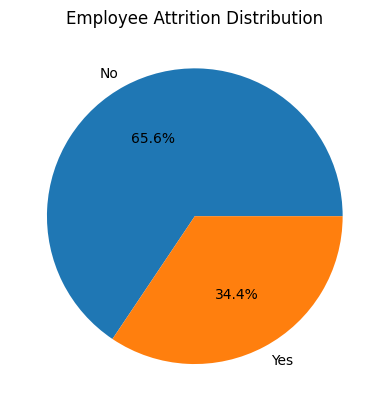

In [ ]:
# attribution  distribution
plt.pie(df['Attrition'].value_counts(), labels=['No', 'Yes'], autopct='%1.1f%%')
plt.title('Employee Attrition Distribution')


Text(0.5, 1.0, 'Attrition by Monthly Income')

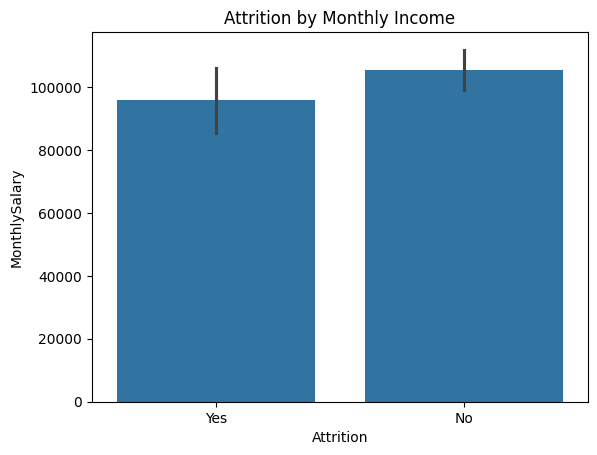

In [ ]:
# attrition by salary
sns.barplot(y='MonthlySalary', x='Attrition', data=df)
plt.title('Attrition by Monthly Income')

Text(0.5, 1.0, 'Attrition by Job Satisfaction')

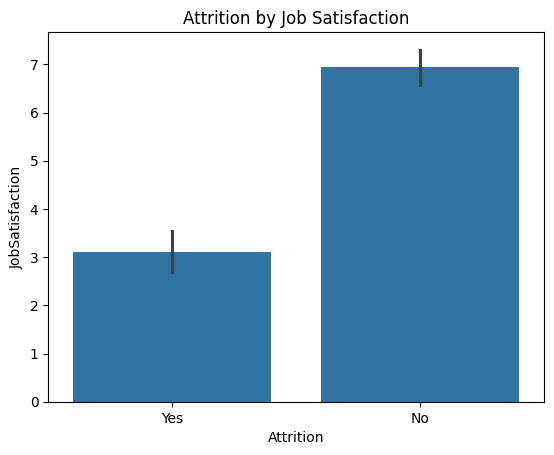

In [ ]:
# why are employees leaving?
sns.barplot(y='JobSatisfaction', x='Attrition', data=df)
plt.title('Attrition by Job Satisfaction')

Text(0.5, 1.0, 'Attrition by Overtime')

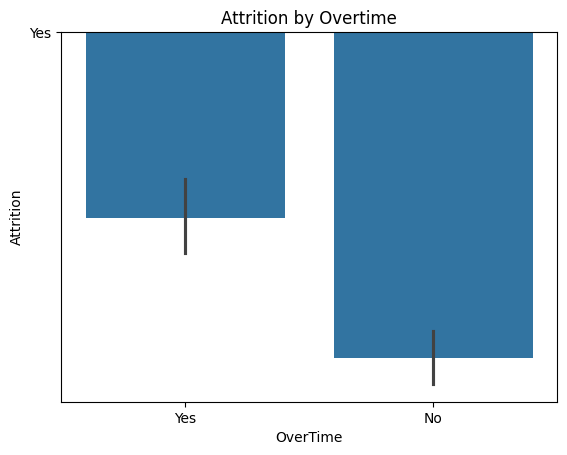

In [ ]:
# overtime
sns.barplot(x='OverTime', y='Attrition', data=df)
plt.title('Attrition by Overtime')

In [ ]:
df[df['OverTime'] == 'Yes']["Attrition"].value_counts()

Attrition
Yes    61
No     53
Name: count, dtype: int64

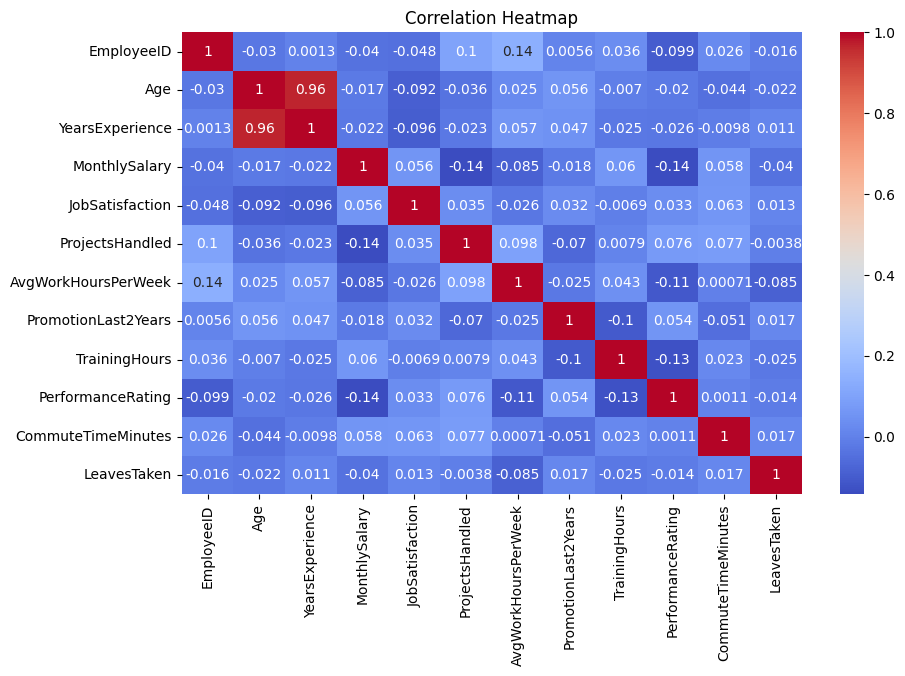

In [ ]:
# correlation
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier